In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.stats import median_abs_deviation as mad
import pandas as pd
plt.style.use('thesis')

## Final 3-label plots
These have been generated using label bounds and a sum-prior with sigma=0.1, flux in original linear space.

In [4]:
spec = np.load('/home/vmehta/honours-project/code/data/sfh_threebins_spectra.npy')
wav = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')
base = '/avatar/vmehta/sfh_1000_3bins_20260402_162314/sumprior-testing'
pred = np.load(f'{base}/snr1000_all_pred.npy')
true = np.load(f'{base}/snr1000_all_true.npy')
res = true - pred

In [5]:
bands1 = []
bands2 = []
bands5 = []
for i in range(10):
    residual = res10[:, i]
    median_residual = np.median(residual)
    lower1 = median_residual - 0.01
    upper1 = median_residual + 0.01
    lower2 = median_residual - 0.02
    upper2 = median_residual + 0.02
    lower5 = median_residual - 0.05
    upper5 = median_residual + 0.05
    bands1.append((lower1, upper1))
    bands2.append((lower2, upper2))
    bands5.append((lower5, upper5))

In [6]:
mad5lower = np.median(res) - 5*mad(res)
mad5upper = np.median(res) + 5*mad(res)
mad5lower, mad5upper

(array([-0.01410531, -0.01146581, -0.00732219]),
 array([0.01393982, 0.01130032, 0.0071567 ]))

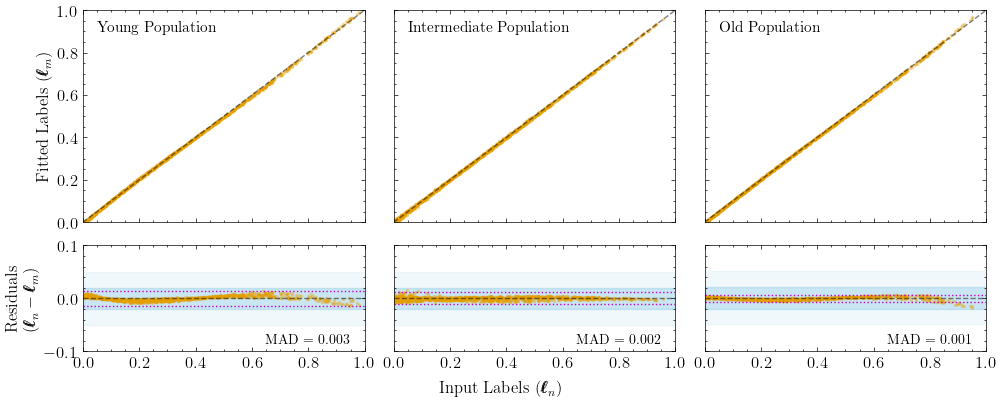

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(10,4), sharey='row', sharex=True, gridspec_kw={'height_ratios': [2, 1]}, constrained_layout=True)

# Draw widest-to-narrowest so inner bands stay visible and intuitive.
band_specs = [
    (bands5, '#cfe8f3', '5% band', 3),
    (bands2, '#73bfe2', '2% band', 4),
]

for i in range(3):
    y_true = true[:, i]
    y_pred = pred[:, i]

    ax[0, i].plot(y_true, y_pred, 'C0.', markersize=3, alpha=0.3)
    ax[1, i].plot(y_true, res[:, i], 'C0.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,1], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].hlines([mad5lower[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5upper[i]], [0], [1], 'm', linestyles='dotted')

    for bands, color, _, z in band_specs:
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    ax[1, i].text(0.95, 0.05, f'MAD = {mad(res[:, i]):.3f}', transform=ax[1, i].transAxes, fontsize=10, va='bottom', ha='right')

ax[0,0].set_ylabel(r'Fitted Labels $(\pmb\ell_m)$', fontsize=12)
ax[1,0].set_ylabel('Residuals\n$(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12, multialignment='center')
ax[0,0].set_xlim(0,1)
ax[0,0].set_ylim(0,1)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12)

ax[1,0].set_ylim(-0.1, 0.1)
ax[0,0].text(0.05, 0.95, 'Young Population', transform=ax[0,0].transAxes, fontsize=11, fontweight='bold', va='top')
ax[0,1].text(0.05, 0.95, 'Intermediate Population', transform=ax[0,1].transAxes, fontsize=11, fontweight='bold', va='top')
ax[0,2].text(0.05, 0.95, 'Old Population', transform=ax[0,2].transAxes, fontsize=11, fontweight='bold', va='top')

#plt.savefig('/home/vmehta/honours-project/thesis/figures/3binmodel.pdf', format='pdf')
plt.show()

In [ ]:
# Summary statistics per population
population_names = ['Young Population', 'Intermediate Population', 'Old Population']
rows = []

tolerances = [
    ('pct_outside_1pct', 0.01),
    ('pct_outside_2pct', 0.02),
    ('pct_outside_5pct', 0.05),
]

for i, name in enumerate(population_names):
    y_true = true[:, i]
    y_pred = pred[:, i]
    residual = y_true - y_pred

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    center = np.median(residual)
    abs_from_center = np.abs(residual - center)

    row = {
        'population': name,
        'r2': r2,
        'mae': np.mean(np.abs(residual)),
        'rmse': np.sqrt(np.mean(residual ** 2)),
        'bias_mean_residual': np.mean(residual),
        'mad': mad(residual),
        'pct_outside_mad5': np.mean(np.abs(residual) > 5*mad(residual)) * 100
    }

    for key, tol in tolerances:
        row[key] = np.mean(abs_from_center > tol) * 100

    rows.append(row)

stats = pd.DataFrame(rows)
stats

,population,r2,mae,rmse,bias_mean_residual,mad,pct_outside_mad5,pct_outside_1pct,pct_outside_2pct,pct_outside_5pct
0,Young Population,0.999665,0.003364,0.004250,0.000155,0.002805,0.0,2.7,0.0,0.0
1,Intermediate Population,0.999808,0.002613,0.003248,-0.000092,0.002277,0.4,0.5,0.0,0.0
2,Old Population,0.999869,0.001919,0.002658,-0.000063,0.001448,1.1,0.8,0.0,0.0


Residual correlation matrix:


,Young,Intermediate,Old
Young,1.000000,-0.780253,-0.644845
Intermediate,-0.780253,1.000000,0.025092
Old,-0.644845,0.025092,1.000000


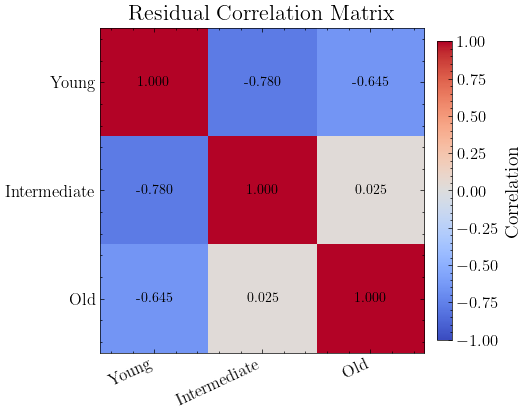

In [ ]:
# Correlation matrix for 3-bin residuals
label_names = ['Young', 'Intermediate', 'Old']

# Residuals are defined above as: res = true - pred
corr_res = np.corrcoef(res, rowvar=False)

corr_df = pd.DataFrame(corr_res, index=label_names, columns=label_names)
print('Residual correlation matrix:')
display(corr_df)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.4), constrained_layout=True)
im = ax.imshow(corr_res, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(label_names, rotation=25, ha='right')
ax.set_yticklabels(label_names)
ax.set_title('Residual Correlation Matrix')

for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr_res[i, j]:.3f}', ha='center', va='center', fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.show()

In [8]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm_vals = [normalize(v) for v in spec]

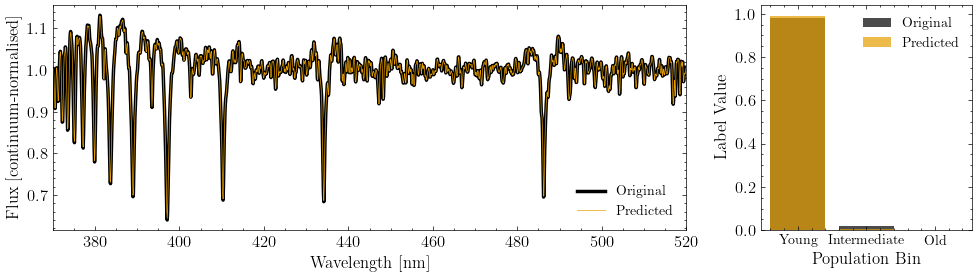

In [ ]:
n = 296

fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex='col',gridspec_kw={'width_ratios': [3, 1]})
ax[0].plot(wav/10, true[n] @ norm_vals, 'k', linewidth=2.5, label='Original')
ax[0].plot(wav/10, pred[n] @ norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[0].legend(fontsize=10, loc='lower right')
ax[0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[0].set_ylabel('Flux [continuum-normalised]', fontsize=12)
ax[0].set_xlim(370, 520)

ax[1].bar(range(len(true[n])), true[n], color='k', alpha=0.7, label='Original')
ax[1].bar(range(len(pred[n])), pred[n], color='C0', alpha=0.7, label='Predicted')
ax[1].legend(fontsize=10)
ax[1].set_xlabel('Population Bin', fontsize=12)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(['Young', 'Intermediate', 'Old'], fontsize=10)
ax[1].set_ylabel('Label Value', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/3binmodel_example.pdf', format='pdf')
plt.show()

## Testing 3 6 and 10 labels with updated model
Log-fluxes vs linear fluxes

In [97]:
lin_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260416_155956/binconf2/newpriorthing/snr1000_all_pred.npy')
lin_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260416_155956/binconf2/newpriorthing/snr1000_all_true.npy')
# log_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_pred.npy')
# log_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_true.npy')

res_lin_6 = lin_pred_6 - lin_true_6
# = log_pred_6 - log_true_6
sixspec = np.load('/home/vmehta/honours-project/code/data/sfh_sixnormalbins_spectra.npy')
six_norm_vals = [normalize(v) for v in sixspec]

In [98]:
mad5lower = np.median(res_lin_6) - 5*mad(res_lin_6)
mad5upper = np.median(res_lin_6) + 5*mad(res_lin_6)
mad5lower, mad5upper

(array([-0.006328  , -0.01924639, -0.02477632, -0.00970326, -0.01974928,
        -0.00917914]),
 array([0.006328  , 0.01924639, 0.02477632, 0.00970326, 0.01974928,
        0.00917914]))

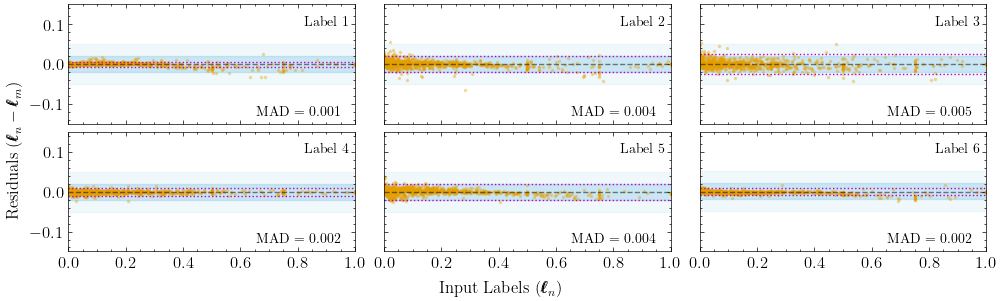

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(10,3), sharex=True, sharey=True, constrained_layout=True)
for i in range(3):
    ax[0, i].plot(lin_true_6[:,i], res_lin_6[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(lin_true_6[:,3+i], res_lin_6[:,3+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].hlines([mad5lower[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5lower[i+3]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].hlines([mad5upper[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5upper[i+3]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].text(0.98, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.98, 0.9, f'Label {i+4}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[0, i].text(0.95, 0.05, f'MAD = {mad(res_lin_6[:,i]):.3f}', transform=ax[0, i].transAxes, fontsize=10, va='bottom', ha='right')
    ax[1, i].text(0.95, 0.05, f'MAD = {mad(res_lin_6[:,3+i]):.3f}', transform=ax[1, i].transAxes, fontsize=10, va='bottom', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)


ax[0,0].set_ylim(-0.15, 0.15)
ax[0,0].set_xlim(0,1)
fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12)
fig.supylabel('Residuals $(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12)

#plt.savefig('/home/vmehta/honours-project/thesis/figures/conf2residuals.pdf', format='pdf')
plt.show()

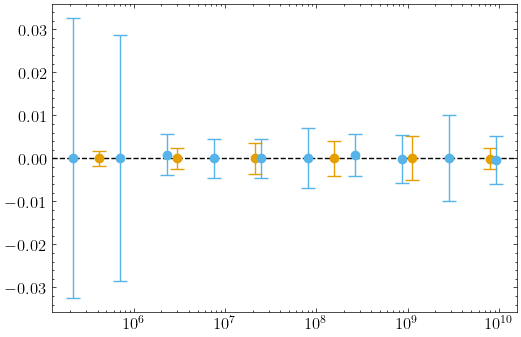

In [33]:
# having a look at rmse
sixbins = np.logspace(5, 10.15, 7)
x6 = [(sixbins[i]+sixbins[i+1])/2 for i in range(6)]
tenbins = np.logspace(5, 10.15, 11)
x10 = [(tenbins[i]+tenbins[i+1])/2 for i in range(10)]

plt.figure(figsize=(6,4))
plt.errorbar(x6, np.median(res_lin_6, axis=0), yerr=mad(res_lin_6, axis=0), fmt='o', color='C0', capsize=5)
plt.errorbar(x10, np.median(res10, axis=0), yerr=mad(res10, axis=0), fmt='o', color='C1', capsize=5)
plt.axhline(0, color='k', linestyle='--')
plt.xscale('log')

In [101]:
# Threshold statistics for 6-label residuals using the defined median-centered bands
threshold_rows = []

for i in range(6):
    r = res_lin_6[:, i]
    b1_lo, b1_hi = bands1[i]
    b2_lo, b2_hi = bands2[i]
    b5_lo, b5_hi = bands5[i]

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows.append({
        'label': f'Label {i+1}',
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
        'pct_outside_mad5': np.mean(np.abs(r) > 5*mad(r)) * 100
    })

threshold_stats_6 = pd.DataFrame(threshold_rows)
threshold_stats_6

,label,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band,pct_outside_mad5
0,Label 1,5.4,0.7,0.0,9.8
1,Label 2,15.8,4.5,0.2,4.7
2,Label 3,27.1,5.7,0.1,2.8
3,Label 4,3.2,0.2,0.0,3.5
4,Label 5,16.7,1.8,0.0,1.9
5,Label 6,3.9,0.2,0.0,4.4


6-bin residual correlation matrix:


,L1,L2,L3,L4,L5,L6
L1,1.000000,-0.979951,0.182348,-0.238275,0.493499,-0.748330
L2,-0.979951,1.000000,-0.337897,0.306588,-0.517739,0.701976
L3,0.182348,-0.337897,1.000000,-0.641997,0.335960,-0.274395
L4,-0.238275,0.306588,-0.641997,1.000000,-0.861271,0.359568
L5,0.493499,-0.517739,0.335960,-0.861271,1.000000,-0.524689
L6,-0.748330,0.701976,-0.274395,0.359568,-0.524689,1.000000


6-bin residual covariance matrix:


,L1,L2,L3,L4,L5,L6
L1,0.000612,-0.000622,0.000035,-0.000046,0.000086,-0.000065
L2,-0.000622,0.000658,-0.000068,0.000062,-0.000094,0.000064
L3,0.000035,-0.000068,0.000061,-0.000039,0.000018,-0.000008
L4,-0.000046,0.000062,-0.000039,0.000061,-0.000048,0.000010
L5,0.000086,-0.000094,0.000018,-0.000048,0.000050,-0.000013
L6,-0.000065,0.000064,-0.000008,0.000010,-0.000013,0.000012


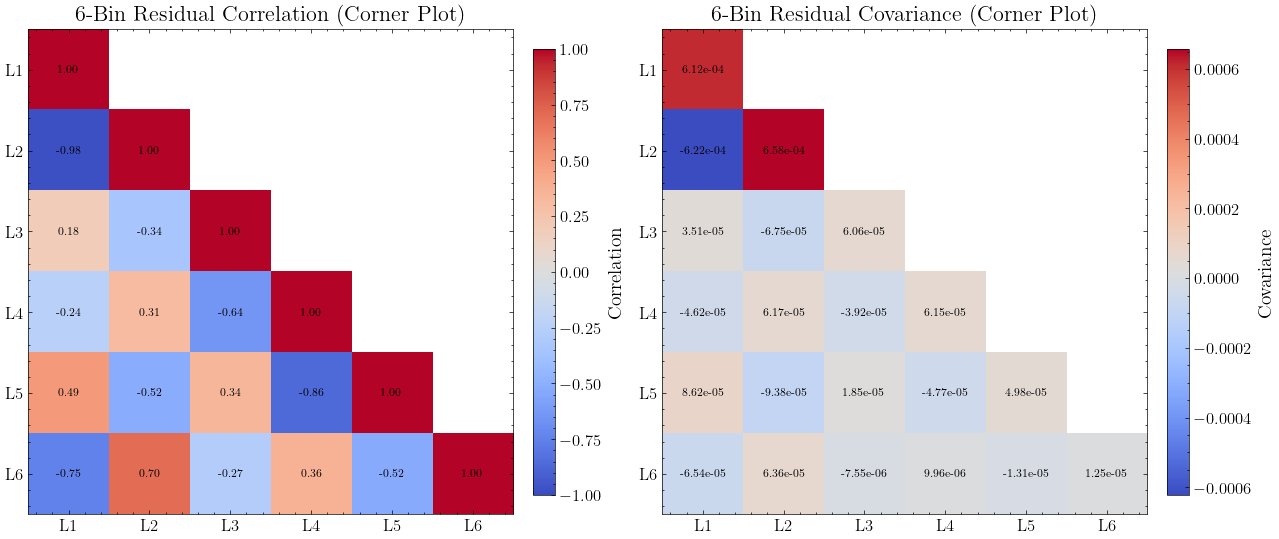

In [29]:
# Correlation + covariance matrices for 6-bin residuals (corner-style)
label_names_6 = [f'L{i+1}' for i in range(6)]

# Residuals for 6-bin model are defined above as: res_lin_6 = lin_pred_6 - lin_true_6
corr_res_6 = np.corrcoef(res_lin_6, rowvar=False)
cov_res_6 = np.cov(res_lin_6, rowvar=False)

corr_df_6 = pd.DataFrame(corr_res_6, index=label_names_6, columns=label_names_6)
cov_df_6 = pd.DataFrame(cov_res_6, index=label_names_6, columns=label_names_6)
print('6-bin residual correlation matrix:')
display(corr_df_6)
print('6-bin residual covariance matrix:')
display(cov_df_6)

# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_6, dtype=bool), k=1)
corr_corner = np.ma.array(corr_res_6, mask=mask_upper)
cov_corner = np.ma.array(cov_res_6, mask=mask_upper)

fig, ax = plt.subplots(1, 2, figsize=(12.8, 5.6), constrained_layout=True)

im0 = ax[0].imshow(corr_corner, cmap='coolwarm', vmin=-1, vmax=1)
ax[0].set_xticks(range(6))
ax[0].set_yticks(range(6))
ax[0].set_xticklabels(label_names_6)
ax[0].set_yticklabels(label_names_6)
ax[0].set_title('6-Bin Residual Correlation (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[0].text(j, i, f'{corr_res_6[i, j]:.2f}', ha='center', va='center', fontsize=8)
cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label('Correlation')

im1 = ax[1].imshow(cov_corner, cmap='coolwarm')
ax[1].set_xticks(range(6))
ax[1].set_yticks(range(6))
ax[1].set_xticklabels(label_names_6)
ax[1].set_yticklabels(label_names_6)
ax[1].set_title('6-Bin Residual Covariance (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[1].text(j, i, f'{cov_res_6[i, j]:.2e}', ha='center', va='center', fontsize=8)
cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
cbar1.set_label('Covariance')

plt.show()

In [41]:
np.argmin(lin_true_6[4])

np.int64(1)

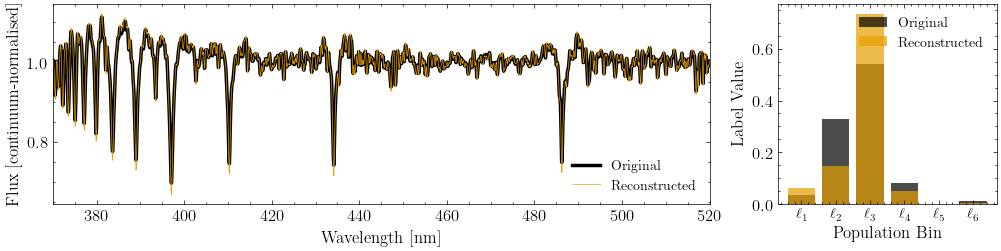

In [95]:
n = 341

fig, ax = plt.subplots(1, 2, figsize=(10,2.5), sharex='col',gridspec_kw={'width_ratios': [3, 1]}, constrained_layout=True)

ax[0].plot(wav/10, lin_true_6[n] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0].plot(wav/10, lin_pred_6[n] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')
ax[0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[0].set_xlim(370, 520)
ax[0].legend(fontsize=10, loc='lower right')
ax[0].set_ylabel('Flux [continuum-normalised]', fontsize=12)

ax[1].bar(range(len(lin_true_6[n])), lin_true_6[n], color='k', alpha=0.7, label='Original')
ax[1].bar(range(len(lin_pred_6[n])), lin_pred_6[n], color='C0', alpha=0.7, label='Reconstructed')
ax[1].legend(fontsize=10)
ax[1].set_xlabel('Population Bin', fontsize=12)
ax[1].set_xticks(range(6))
ax[1].set_xticklabels([f'$\\ell_{{{i}}}$' for i in range(1, 7)], fontsize=10)
ax[1].set_ylabel('Label Value', fontsize=12)

#plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/conf1spec.pdf', format='pdf')
plt.show()

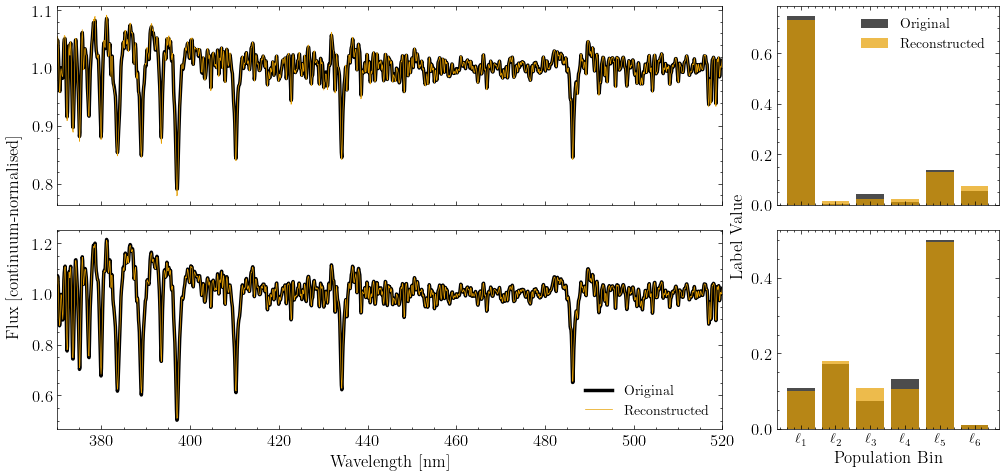

In [91]:
n = 633
m = 172

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, lin_true_6[n] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, lin_pred_6[n] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')

ax[1,0].plot(wav/10, lin_true_6[m] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, lin_pred_6[m] @ six_norm_vals, 'C0', linewidth=0.5, label='Reconstructed')
ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right')

ax[0,1].bar(range(len(lin_true_6[n])), lin_true_6[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(lin_pred_6[n])), lin_pred_6[n], color='C0', alpha=0.7, label='Reconstructed')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(lin_true_6[m])), lin_true_6[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(lin_pred_6[m])), lin_pred_6[m], color='C0', alpha=0.7, label='Reconstructed')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(6))
ax[1,1].set_xticklabels([f'$\\ell_{{{i}}}$' for i in range(1, 7)], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/6binspec.pdf', format='pdf')
plt.show()

In [94]:
np.where(res_lin_6 == np.max(res_lin_6))

(array([341]), array([2]))

## 10-label plots

In [79]:
f10 = '/avatar/vmehta/sfh_1000_10bins_20260414_140539/finalmodel/newpriorthing'
pred10 = np.load(f'{f10}/snr1000_all_pred.npy')
true10 = np.load(f'{f10}/snr1000_all_true.npy')
res10 = pred10 - true10
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tennormalbins_spectra.npy')

ten_norm_vals = [normalize(v) for v in spec10]

In [80]:
mean_fluxes = np.mean(spec10, axis=1)
total_fluxes = []
for i in range(len(true10)):
    total_flux = np.dot(true10[i], mean_fluxes)
    total_fluxes.append(total_flux)

flux_contributions = np.zeros((1000, 10))
for i in range(1000):
    for j in range(10):
        flux_contributions[i, j] = (true10[i, j] * mean_fluxes[j]) / total_fluxes[i]

In [81]:
mad5lower = np.median(res10) - 5*mad(res10)
mad5upper = np.median(res10) + 5*mad(res10)
mad5lower, mad5upper

(array([-0.00893735, -0.02892135, -0.04523626, -0.04176044, -0.02682232,
        -0.02739456, -0.0974541 , -0.17640465, -0.18911005, -0.09153998]),
 array([0.00893735, 0.02892135, 0.04523626, 0.04176044, 0.02682232,
        0.02739456, 0.0974541 , 0.17640465, 0.18911005, 0.09153998]))

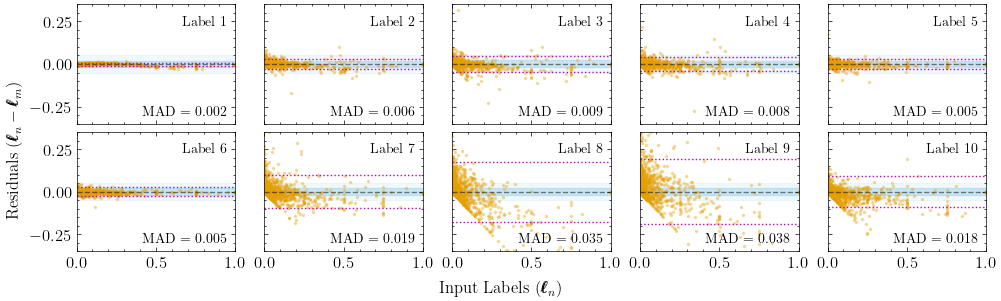

In [82]:
fig, ax = plt.subplots(2, 5, figsize=(10,3), sharex=True, sharey=True, constrained_layout=True)
for i in range(5):
    ax[0, i].plot(true10[:,i], res10[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(true10[:,5+i], res10[:,5+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].hlines([mad5lower[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5lower[i+5]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].hlines([mad5upper[i]], [0], [1], 'm', linestyles='dotted')
    ax[1, i].hlines([mad5upper[i+5]], [0], [1], 'm', linestyles='dotted')
    ax[0, i].text(0.95, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.95, 0.9, f'Label {i+6}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[0, i].text(0.95, 0.05, f'MAD = {mad(res10[:,i]):.3f}', transform=ax[0, i].transAxes, fontsize=10, va='bottom', ha='right')
    ax[1, i].text(0.95, 0.05, f'MAD = {mad(res10[:,5+i]):.3f}', transform=ax[1, i].transAxes, fontsize=10, va='bottom', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)

ax[0,0].set_ylim(-0.35, 0.35)
ax[0,0].set_xlim(0,1)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12)
fig.supylabel('Residuals $(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12)

#plt.savefig('/home/vmehta/honours-project/thesis/figures/10binresiduals.pdf', format='pdf')
plt.show()

In [ ]:
# Tolerance statistics for 10-label residuals
# Uses median-centered bands per label, analogous to the 3/6-label stats.
threshold_rows_10 = []

for i in range(10):
    r = res10[:, i]
    center = np.median(r)

    b1_lo, b1_hi = center - 0.01, center + 0.01
    b2_lo, b2_hi = center - 0.02, center + 0.02
    b5_lo, b5_hi = center - 0.05, center + 0.05

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows_10.append({
        'label': f'Label {i+1}',
        'median_residual': center,
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
        'pct_outside_mad5': np.mean(np.abs(r) > 5*mad(r)) * 100
    })

threshold_stats_10 = pd.DataFrame(threshold_rows_10)
threshold_stats_10

,label,median_residual,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band,pct_outside_mad5
0,Label 1,-1.293942e-08,73.1,61.1,41.7,14.5
1,Label 2,0.000000e+00,70.5,56.9,38.3,14.9
2,Label 3,8.945420e-04,25.7,10.3,2.3,8.3
3,Label 4,-3.587086e-07,20.1,4.8,0.7,3.4
4,Label 5,1.659776e-35,23.1,4.4,0.1,3.5
5,Label 6,-2.103583e-05,37.9,13.1,0.6,1.8
6,Label 7,7.428578e-04,25.2,4.9,0.1,2.3
7,Label 8,-1.508454e-04,32.1,10.0,0.5,4.6
8,Label 9,3.353128e-17,49.9,27.2,3.8,3.8
9,Label 10,-3.024348e-04,28.5,6.6,0.8,2.8


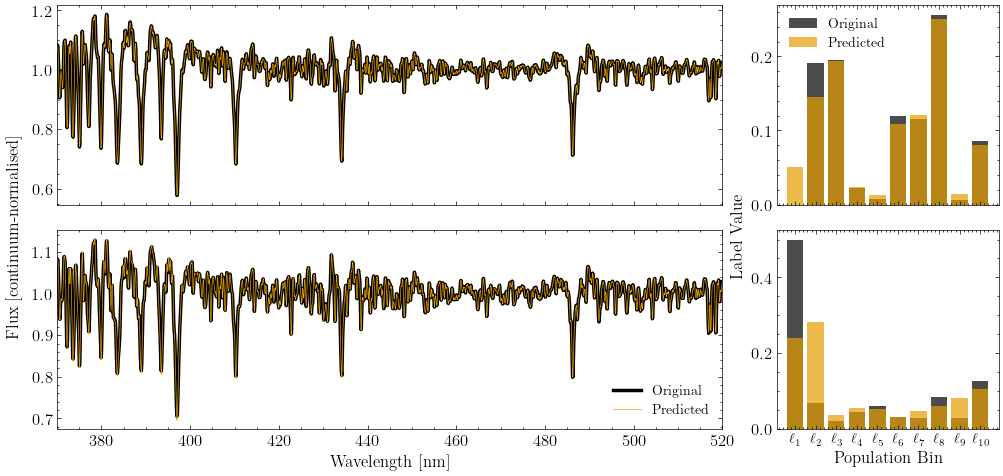

In [ ]:
n = 0
m = 2

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, true10[n] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, pred10[n] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')

ax[1,0].plot(wav/10, true10[m] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, pred10[m] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right')

ax[0,1].bar(range(len(true10[n])), true10[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(pred10[n])), pred10[n], color='C0', alpha=0.7, label='Predicted')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(true10[m])), true10[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(pred10[m])), pred10[m], color='C0', alpha=0.7, label='Predicted')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(10))
ax[1,1].set_xticklabels([f'$\\ell_1$', f'$\\ell_2$', f'$\\ell_3$', f'$\\ell_4$', f'$\\ell_5$', f'$\\ell_6$', f'$\\ell_7$', f'$\\ell_8$', f'$\\ell_9$', f'$\\ell_{{10}}$'], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/10binmodel_example.pdf', format='pdf')
plt.show()

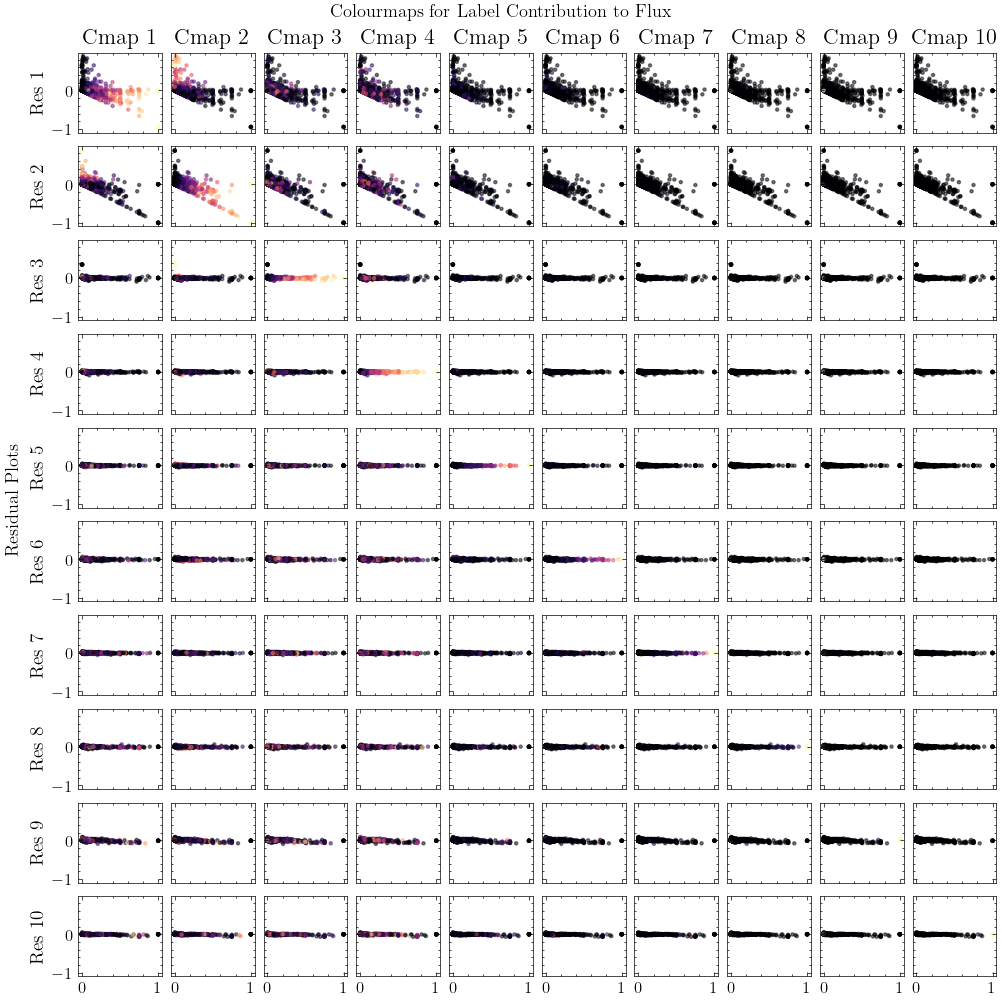

In [ ]:
fig, ax = plt.subplots(10, 10, figsize=(10,10), sharex=True, sharey=True, constrained_layout=True)
for i in range(10):
    for j in range(10):
        ax[i,j].scatter(true10[:,i], res10[:,i], s=5, c=flux_contributions[:,j], cmap='magma', alpha=0.5)
        ax[i,0].set_ylabel(f'Res {i+1}')
        ax[0,j].set_title(f'Cmap {j+1}')

fig.supylabel('Residual Plots')
fig.suptitle('Colourmaps for Label Contribution to Flux')
plt.show()

10-label residual correlation matrix:


,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
L1,1.000000,-0.976997,0.299874,-0.393211,0.395001,-0.335074,-0.046441,-0.089415,-0.306961,0.014174
L2,-0.976997,1.000000,-0.492312,0.313350,-0.368362,0.319380,0.032737,0.086365,0.289582,-0.035262
L3,0.299874,-0.492312,1.000000,0.046481,0.034289,-0.074785,0.047688,-0.008982,0.005184,0.031208
L4,-0.393211,0.313350,0.046481,1.000000,-0.315033,0.299569,-0.081031,0.040650,-0.180789,0.371770
L5,0.395001,-0.368362,0.034289,-0.315033,1.000000,-0.903470,0.279591,-0.053637,-0.027156,-0.066889
L6,-0.335074,0.319380,-0.074785,0.299569,-0.903470,1.000000,-0.552846,0.305764,-0.250806,0.313254
L7,-0.046441,0.032737,0.047688,-0.081031,0.279591,-0.552846,1.000000,-0.866523,0.619505,-0.491793
L8,-0.089415,0.086365,-0.008982,0.040650,-0.053637,0.305764,-0.866523,1.000000,-0.682054,0.617920
L9,-0.306961,0.289582,0.005184,-0.180789,-0.027156,-0.250806,0.619505,-0.682054,1.000000,-0.917071
L10,0.014174,-0.035262,0.031208,0.371770,-0.066889,0.313254,-0.491793,0.617920,-0.917071,1.000000


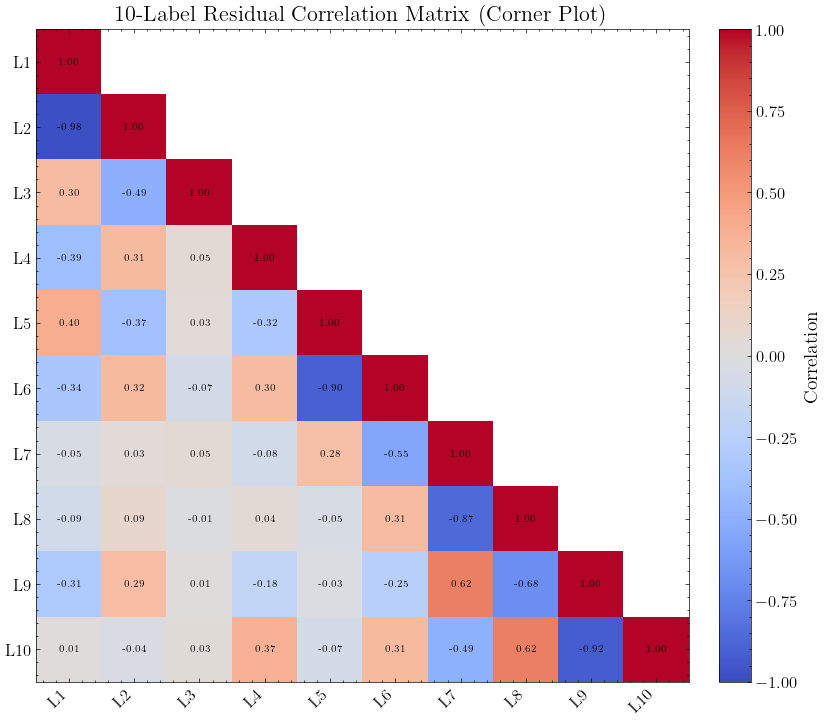

In [ ]:
# Correlation matrix for 10-label residuals (corner-style)
label_names_10 = [f'L{i+1}' for i in range(10)]

# Residuals for 10-label model are defined above as: res10 = pred10 - true10
corr_res_10 = np.corrcoef(res10, rowvar=False)

corr_df_10 = pd.DataFrame(corr_res_10, index=label_names_10, columns=label_names_10)
print('10-label residual correlation matrix:')
display(corr_df_10)

# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_10, dtype=bool), k=1)
corr_corner_10 = np.ma.array(corr_res_10, mask=mask_upper)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 7.2), constrained_layout=True)
im = ax.imshow(corr_corner_10, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names_10, rotation=45, ha='right')
ax.set_yticklabels(label_names_10)
ax.set_title('10-Label Residual Correlation Matrix (Corner Plot)')

for i in range(10):
    for j in range(i + 1):
        ax.text(j, i, f'{corr_res_10[i, j]:.2f}', ha='center', va='center', fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.show()

263

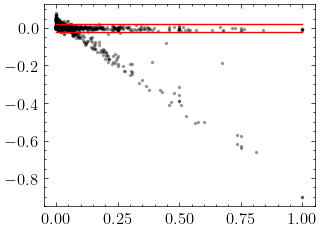

In [ ]:
plt.plot(true10[:,3], res10[:,3], 'k.', markersize=3, alpha=0.3)
plt.plot([0,1], [-0.02, -0.02], 'r')
plt.plot([0,1], [0.02, 0.02], 'r')
fails = res10[:,3][(res10[:,3] < -0.02) | (res10[:,3] > 0.02)]
len(fails)

In [ ]:
df = pd.DataFrame(res10)